In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

In [6]:
df = pd.read_csv(r"D:\CSE(DataScience)\Customer_Churn_Prediction\Datasets\Telco-Customer-Churn-dataset.csv")

In [7]:
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print(df.head())

Shape: (7043, 21)
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1               

In [8]:
if "customerID" in df.columns:
    df.drop(columns=["customerID"], inplace=True)

In [10]:
# Convert TotalCharges to numeric safely
if "TotalCharges" in df.columns:
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
    
    # Handle NaN if any
    if df["TotalCharges"].isnull().sum() > 0:
        df["TotalCharges"].fillna(df["TotalCharges"].median(skipna=True), inplace=True)
else:
    print("⚠️ Column 'TotalCharges' not found in dataset.")

In [11]:
# Encode Target
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

C:\Users\dhana\AppData\Local\Temp\ipykernel_8876\3227985121.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Churn", data=df, palette="coolwarm")


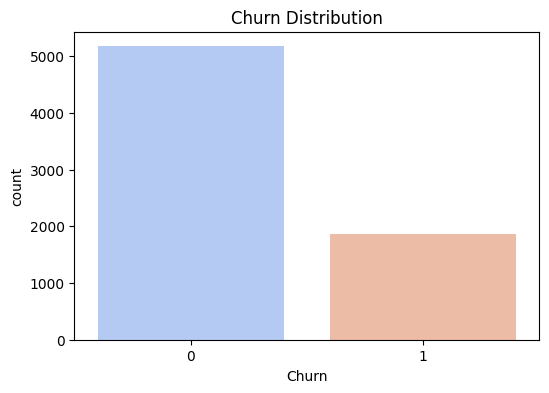

In [12]:
# Target Distribution
plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=df, palette="coolwarm")
plt.title("Churn Distribution")
plt.show()

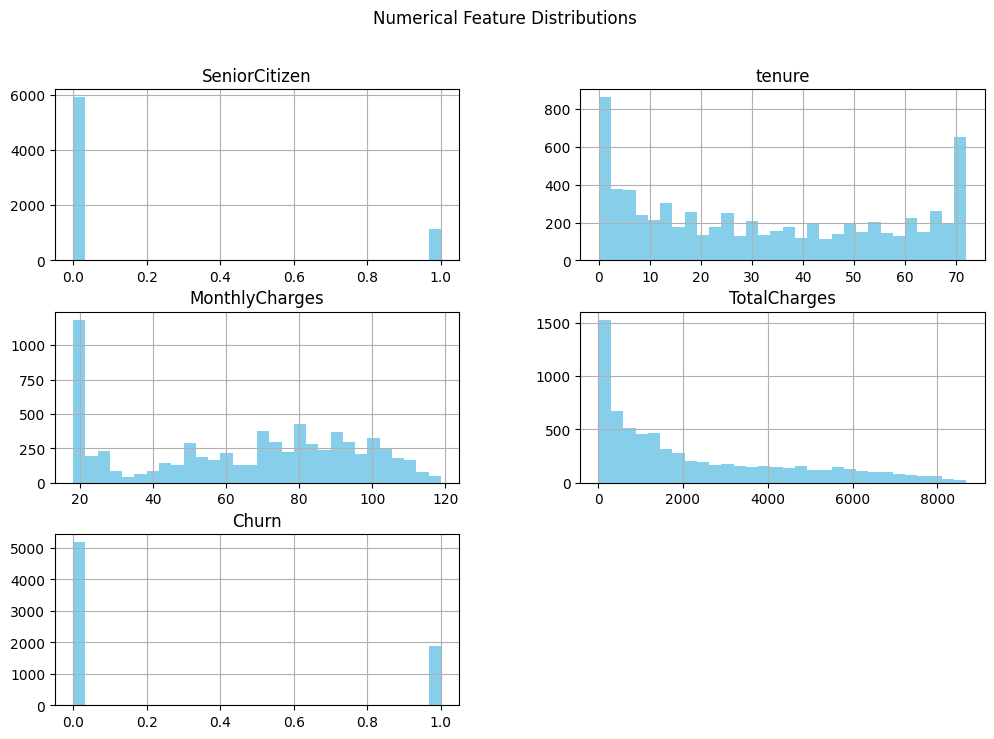

In [13]:
# Numerical Features Distribution
num_cols = df.select_dtypes(include=["int64","float64"]).columns
df[num_cols].hist(bins=30, figsize=(12,8), color="skyblue")
plt.suptitle("Numerical Feature Distributions")
plt.show()

C:\Users\dhana\AppData\Local\Temp\ipykernel_8876\2587091810.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_rate.index, y=churn_rate.values, palette="viridis")


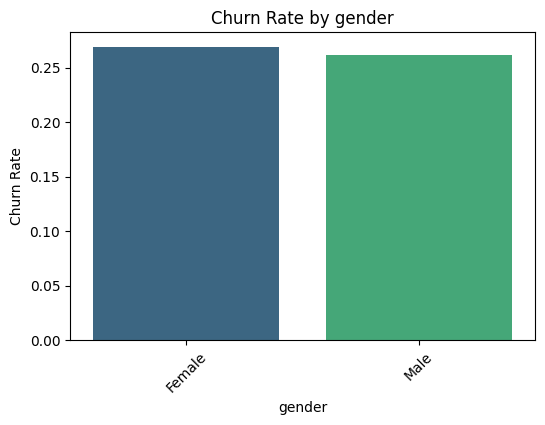

C:\Users\dhana\AppData\Local\Temp\ipykernel_8876\2587091810.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_rate.index, y=churn_rate.values, palette="viridis")


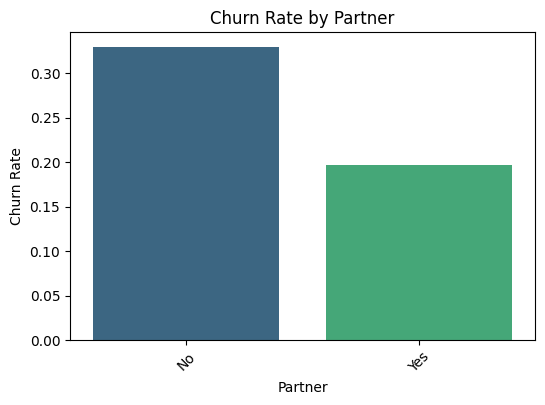

C:\Users\dhana\AppData\Local\Temp\ipykernel_8876\2587091810.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_rate.index, y=churn_rate.values, palette="viridis")


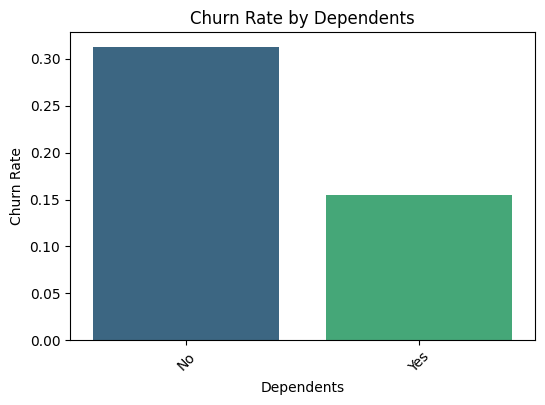

C:\Users\dhana\AppData\Local\Temp\ipykernel_8876\2587091810.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_rate.index, y=churn_rate.values, palette="viridis")


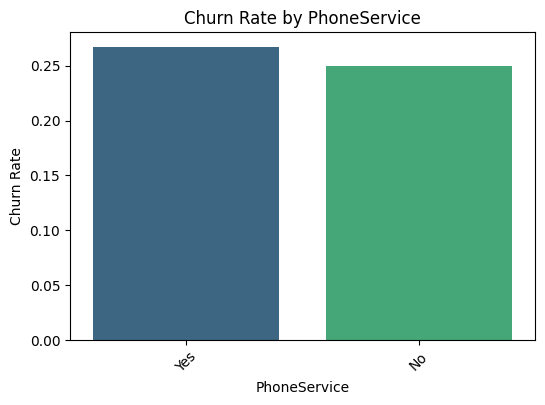

C:\Users\dhana\AppData\Local\Temp\ipykernel_8876\2587091810.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_rate.index, y=churn_rate.values, palette="viridis")


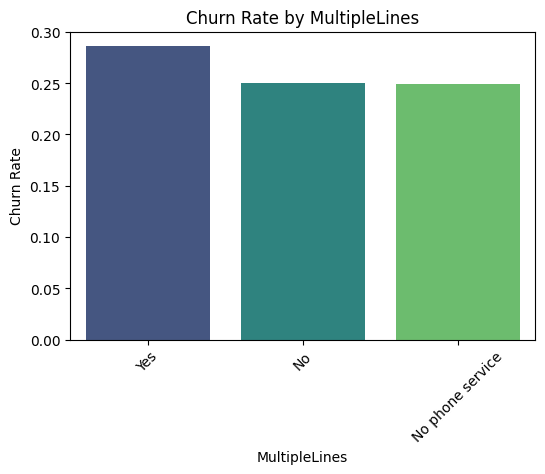

C:\Users\dhana\AppData\Local\Temp\ipykernel_8876\2587091810.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_rate.index, y=churn_rate.values, palette="viridis")


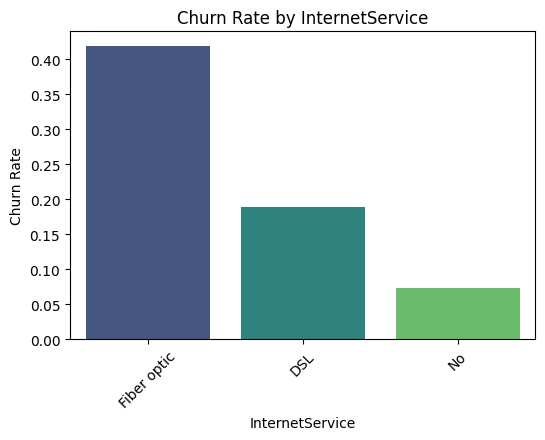

C:\Users\dhana\AppData\Local\Temp\ipykernel_8876\2587091810.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_rate.index, y=churn_rate.values, palette="viridis")


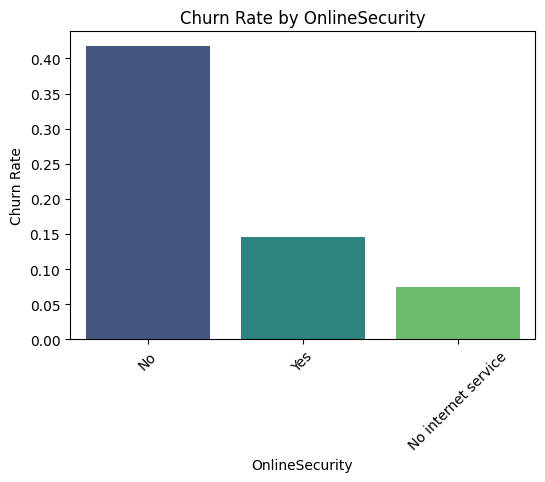

C:\Users\dhana\AppData\Local\Temp\ipykernel_8876\2587091810.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_rate.index, y=churn_rate.values, palette="viridis")


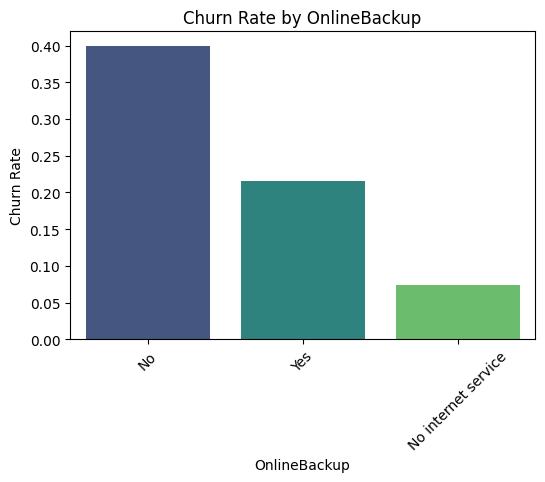

C:\Users\dhana\AppData\Local\Temp\ipykernel_8876\2587091810.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_rate.index, y=churn_rate.values, palette="viridis")


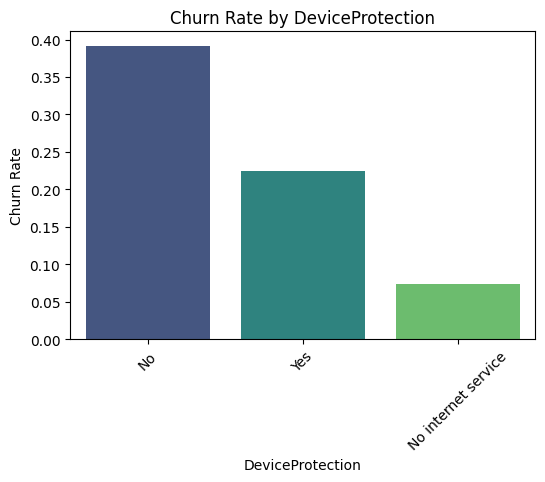

C:\Users\dhana\AppData\Local\Temp\ipykernel_8876\2587091810.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_rate.index, y=churn_rate.values, palette="viridis")


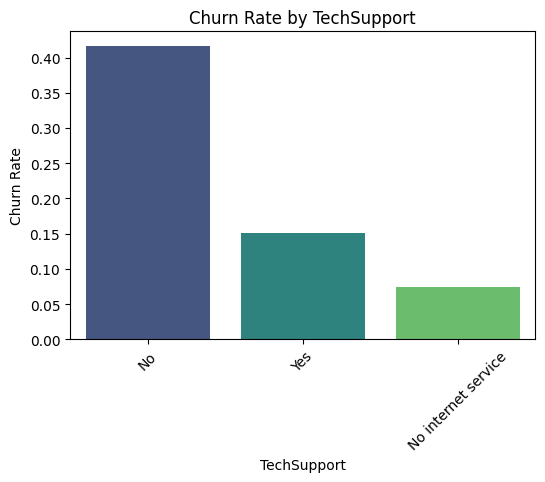

C:\Users\dhana\AppData\Local\Temp\ipykernel_8876\2587091810.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_rate.index, y=churn_rate.values, palette="viridis")


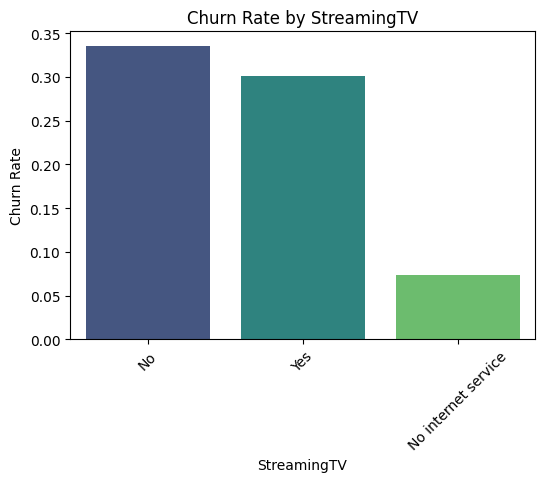

C:\Users\dhana\AppData\Local\Temp\ipykernel_8876\2587091810.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_rate.index, y=churn_rate.values, palette="viridis")


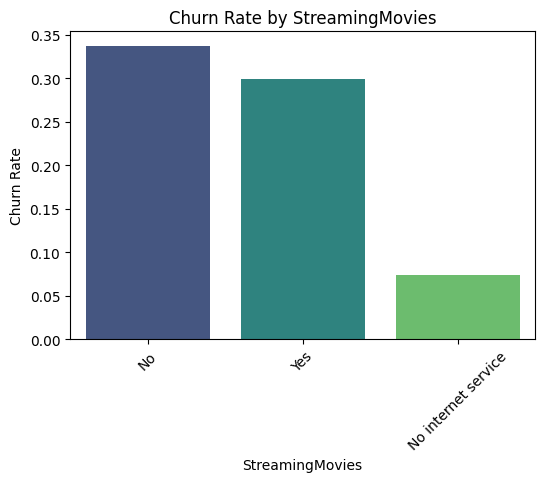

C:\Users\dhana\AppData\Local\Temp\ipykernel_8876\2587091810.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_rate.index, y=churn_rate.values, palette="viridis")


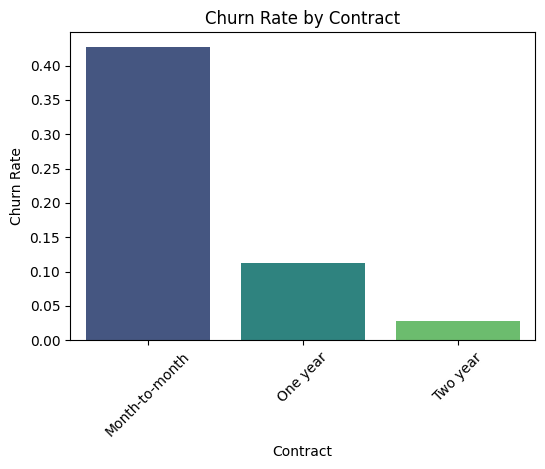

C:\Users\dhana\AppData\Local\Temp\ipykernel_8876\2587091810.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_rate.index, y=churn_rate.values, palette="viridis")


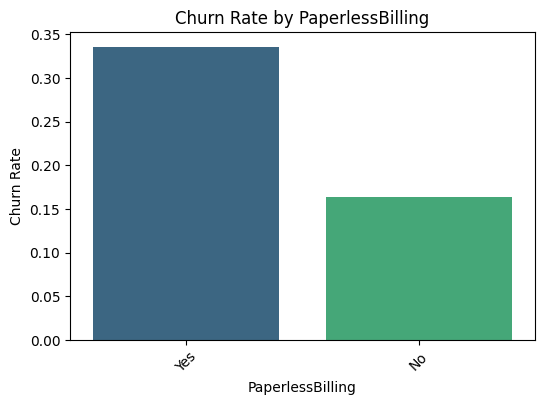

C:\Users\dhana\AppData\Local\Temp\ipykernel_8876\2587091810.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_rate.index, y=churn_rate.values, palette="viridis")


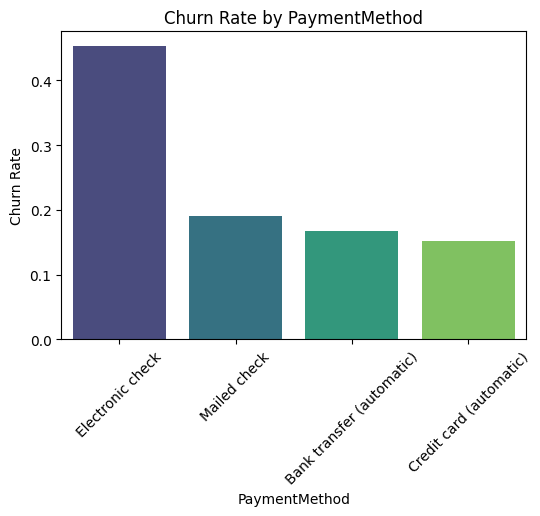

In [14]:
# Categorical Features Churn Rate
cat_cols = df.select_dtypes(include=["object"]).columns
for col in cat_cols:
    plt.figure(figsize=(6,4))
    churn_rate = df.groupby(col)["Churn"].mean().sort_values(ascending=False)
    sns.barplot(x=churn_rate.index, y=churn_rate.values, palette="viridis")
    plt.xticks(rotation=45)
    plt.title(f"Churn Rate by {col}")
    plt.ylabel("Churn Rate")
    plt.show()

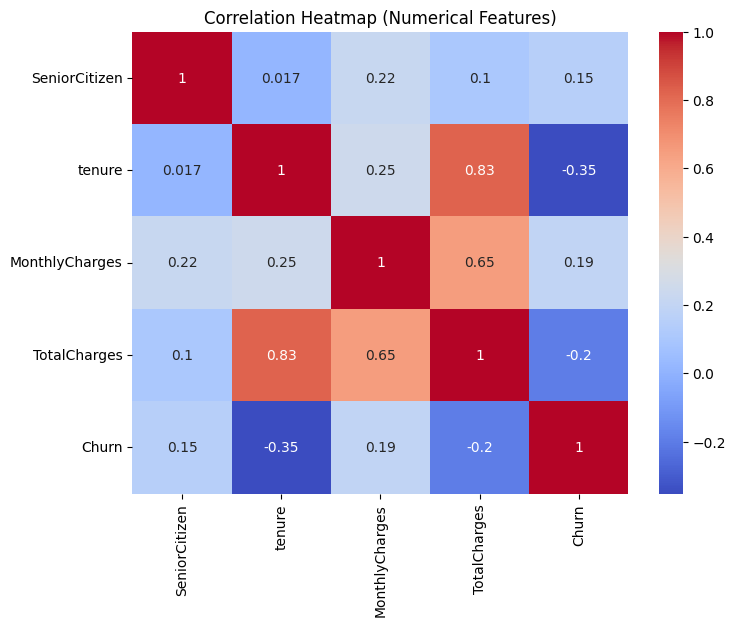

In [15]:
# Correlation Heatmap (Numerical)
plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Numerical Features)")
plt.show()

In [16]:
# -------------------- Train/Test Split --------------------
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [18]:
# -------------------- Preprocessing --------------------
num_cols = X.select_dtypes(include=["int64","float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

In [19]:
# -------------------- Best Model: SVM --------------------
svm_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", SVC(probability=True, random_state=42))
])

In [20]:
svm_pipeline.fit(X_train, y_train)
y_pred = svm_pipeline.predict(X_test)
y_prob = svm_pipeline.predict_proba(X_test)[:,1]

In [21]:
# -------------------- Evaluation --------------------
print("\n=== Classification Report (SVM) ===")
print(classification_report(y_test, y_pred))

print("AUC Score:", roc_auc_score(y_test, y_prob))


=== Classification Report (SVM) ===
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.48      0.55       374

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409

AUC Score: 0.7904905835852127


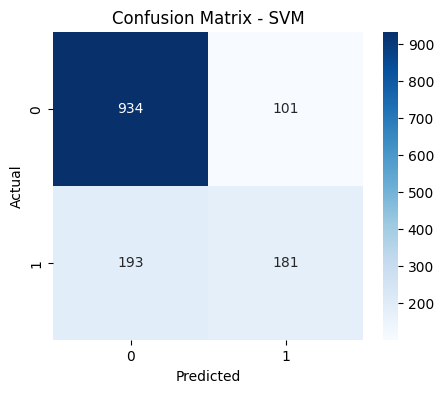

In [22]:
# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

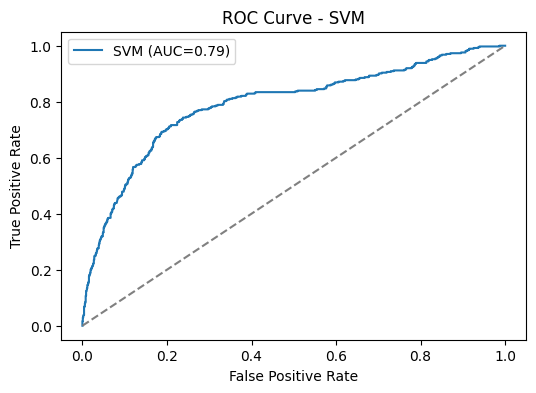

In [23]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"SVM (AUC={roc_auc_score(y_test,y_prob):.2f})")
plt.plot([0,1],[0,1],'--',color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM")
plt.legend()
plt.show()

🔹 Loading trained SVM pipeline...
✅ Model loaded successfully!


C:\Users\dhana\AppData\Local\Temp\ipykernel_8876\585836454.py:84: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dhana\AppData\Local\Temp\ipykernel_8876\585836454.py:88: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path)
C:\Users\dhana\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


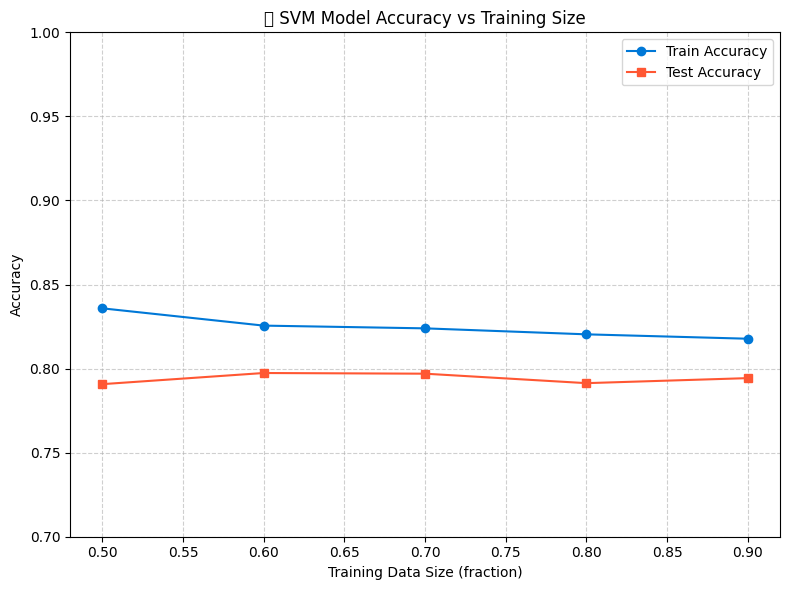


✅ Plot saved to: D:\CSE(DataScience)\Customer_Churn_Prediction\outputs\svm_train_vs_test_accuracy.png


In [25]:
# ===================================================
# Telco Customer Churn - SVM Train vs Test Accuracy Plot
# ===================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# -------------------- Paths --------------------
DATA_PATH = r"D:\CSE(DataScience)\Customer_Churn_Prediction\Datasets\Telco-Customer-Churn-dataset.csv"
MODEL_PATH = r"D:\CSE(DataScience)\Customer_Churn_Prediction\models\churn_pipeline_svm.pkl"
OUTPUT_DIR = r"D:\CSE(DataScience)\Customer_Churn_Prediction\outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# -------------------- Load Dataset --------------------
df = pd.read_csv(DATA_PATH)

# Drop customerID if exists
if "customerID" in df.columns:
    df.drop(columns=["customerID"], inplace=True, errors='ignore')

# Convert TotalCharges safely to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Fill missing TotalCharges values with median (safe version)
median_total = df["TotalCharges"].median(skipna=True)
df["TotalCharges"] = df["TotalCharges"].fillna(median_total)

# Encode Churn column
if "Churn" in df.columns:
    df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# Drop any remaining NaN values
df.dropna(subset=["Churn"], inplace=True)


# Split
X = df.drop("Churn", axis=1)
y = df["Churn"]

# We'll test different train sizes to see how accuracy varies
train_sizes = np.linspace(0.5, 0.9, 5)  # 50%, 60%, 70%, 80%, 90%
train_accuracies = []
test_accuracies = []

# -------------------- Load Model --------------------
print("🔹 Loading trained SVM pipeline...")
svm_pipeline = joblib.load(MODEL_PATH)
print("✅ Model loaded successfully!")

# -------------------- Evaluate on different splits --------------------
for size in train_sizes:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, train_size=size, random_state=42, stratify=y
    )
    # Train on training portion
    svm_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_train_pred = svm_pipeline.predict(X_train)
    y_test_pred = svm_pipeline.predict(X_test)
    
    # Accuracies
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

# -------------------- Plot Results --------------------
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_accuracies, marker='o', label='Train Accuracy', color='#0078D7')
plt.plot(train_sizes, test_accuracies, marker='s', label='Test Accuracy', color='#FF5733')
plt.title("📊 SVM Model Accuracy vs Training Size")
plt.xlabel("Training Data Size (fraction)")
plt.ylabel("Accuracy")
plt.ylim(0.7, 1.0)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()

# Save plot
save_path = os.path.join(OUTPUT_DIR, "svm_train_vs_test_accuracy.png")
plt.savefig(save_path)
plt.show()

print("\n✅ Plot saved to:", save_path)
